In [17]:
import tensorflow as tf
from keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub

import os

In [2]:
# Load data
path = kagglehub.dataset_download("palbha/cmapss-jet-engine-simulated-data")

# Print all files in downloaded dataset
print("All files in dataset: ")
os.listdir(path)

All files in dataset: 


['Damage Propagation Modeling.pdf',
 'train_FD001.txt',
 'train_FD003.txt',
 'RUL_FD004.txt',
 'train_FD002.txt',
 'RUL_FD001.txt',
 'RUL_FD003.txt',
 'RUL_FD002.txt',
 'train_FD004.txt',
 'test_FD003.txt',
 'test_FD002.txt',
 'test_FD001.txt',
 'test_FD004.txt',
 'readme.txt']

In [3]:
# Add column names to data set
df_train = pd.read_csv(os.path.join(path, 'train_FD001.txt'), sep=' ', header=None)
df_test = pd.read_csv(os.path.join(path, 'test_FD001.txt'), sep=' ', header=None)
col_names = ['Unit', 'Cycle Time'] + [f'Operational Setting {_+1}' for _ in range(3)] + [f'Sensor {_+1}' for _ in range(23)]

df_test.columns = col_names
df_train.columns = col_names

df_test.head()

,Unit,Cycle Time,Operational Setting 1,Operational Setting 2,Operational Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Sensor 22,Sensor 23
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,NaN,NaN
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,NaN,NaN
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,NaN,NaN
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,NaN,NaN
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,NaN,NaN


In [7]:
# Choose which features
# Sensors to drop: 1, 5, 6, 10, 16, 17, 18, 19, (22, 23?)
irrelevant_sensors = [1, 5, 6, 10, 16, 17, 18, 19, 22, 23]

relevant_sensors = [f'Sensor {_+1}' for _ in range(23)]
for i in [f'Sensor {_}' for _ in irrelevant_sensors]:
    relevant_sensors.remove(i)
print("Relevant columns: ", relevant_sensors)

other_cols_to_drop = ['Operational Setting 1', 'Operational Setting 2', 'Operational Setting 3']
relevant_cols = ['Unit', 'Cycle Time'] + other_cols_to_drop + relevant_sensors

for i in other_cols_to_drop:
    relevant_cols.remove(i)

print("Relevant columns: ", relevant_cols)

Relevant columns:  ['Sensor 2', 'Sensor 3', 'Sensor 4', 'Sensor 7', 'Sensor 8', 'Sensor 9', 'Sensor 11', 'Sensor 12', 'Sensor 13', 'Sensor 14', 'Sensor 15', 'Sensor 20', 'Sensor 21']
Relevant columns:  ['Unit', 'Cycle Time', 'Sensor 2', 'Sensor 3', 'Sensor 4', 'Sensor 7', 'Sensor 8', 'Sensor 9', 'Sensor 11', 'Sensor 12', 'Sensor 13', 'Sensor 14', 'Sensor 15', 'Sensor 20', 'Sensor 21']


In [8]:
df_test = df_test[relevant_cols]
df_train = df_train[relevant_cols]

# print(df_test.head())

# Normalize all features

# Try z-score normalization
z_score_scaled_df_train = df_train[relevant_cols].copy()
z_score_scaled_df_test = df_train[relevant_cols].copy()



for sensor in relevant_sensors:
    z_score_scaled_df_train[sensor] = (df_train[sensor] - df_train[sensor].mean()) \
    / df_train[sensor].std()
    z_score_scaled_df_test[sensor] = (df_test[sensor] - df_test[sensor].mean()) \
    / df_test[sensor].std()

    # print("Shape: ", z_score_scaled_df_train[sensor].shape)

z_score_scaled_df_train.head()

,Unit,Cycle Time,Sensor 2,Sensor 3,Sensor 4,Sensor 7,Sensor 8,Sensor 9,Sensor 11,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 20,Sensor 21
0,1,1,-1.721684,-0.134252,-0.925914,1.121113,-0.516326,-0.862792,-0.266460,0.334254,-1.058865,-0.269065,-0.603801,1.348460,1.194398
1,1,2,-1.061754,0.211523,-0.643710,0.431920,-0.798074,-0.958794,-0.191578,1.174871,-0.363637,-0.642829,-0.275845,1.016503,1.236892
2,1,3,-0.661797,-0.413156,-0.525940,1.008131,-0.234578,-0.557126,-1.015279,1.364688,-0.919819,-0.551616,-0.649128,0.739873,0.503411
3,1,4,-0.661797,-1.261284,-0.784812,1.222798,0.188044,-0.713808,-1.539452,1.961255,-0.224592,-0.520163,-1.971617,0.352590,0.777773
4,1,5,-0.621801,-1.251498,-0.301511,0.714376,-0.516326,-0.457048,-0.977838,1.052846,-0.780774,-0.521736,-0.339837,0.463242,1.059526


In [ ]:
# Normalize all features
# Try z-score normalization
z_score_scaled_df_train = df_train[relevant_cols].copy()
z_score_scaled_df_test = df_train[relevant_cols].copy()

for sensor in relevant_sensors:
    z_score_scaled_df_train[sensor] = (df_train[sensor] - df_train[sensor].mean()) \
    / df_train[sensor].std()
    z_score_scaled_df_test[sensor] = (df_test[sensor] - df_test[sensor].mean()) \
    / df_test[sensor].std()

    # print("Shape: ", z_score_scaled_df_train[sensor].shape)

# z_score_scaled_df_train.head()

   Unit  Cycle Time  Sensor 2  Sensor 3  Sensor 4  Sensor 7  Sensor 8  \
0     1           1    643.02   1585.29   1398.21    553.90   2388.04   
1     1           2    641.71   1588.45   1395.42    554.85   2388.01   
2     1           3    642.46   1586.94   1401.34    554.11   2388.05   
3     1           4    642.44   1584.12   1406.42    554.07   2388.03   
4     1           5    642.51   1587.19   1401.92    554.16   2388.01   

   Sensor 9  Sensor 11  Sensor 12  Sensor 13  Sensor 14  Sensor 15  Sensor 20  \
0   9050.17      47.20     521.72    2388.03    8125.55     8.4052      38.86   
1   9054.42      47.50     522.16    2388.06    8139.62     8.3803      39.02   
2   9056.96      47.50     521.97    2388.03    8130.10     8.4441      39.08   
3   9045.29      47.28     521.38    2388.05    8132.90     8.3917      39.00   
4   9044.55      47.31     522.15    2388.03    8129.54     8.4031      38.99   

   Sensor 21  
0    23.3735  
1    23.3916  
2    23.4166  
3    23.3737  

,Unit,Cycle Time,Sensor 2,Sensor 3,Sensor 4,Sensor 7,Sensor 8,Sensor 9,Sensor 11,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 20,Sensor 21
0,1,1,-1.721684,-0.134252,-0.925914,1.121113,-0.516326,-0.862792,-0.266460,0.334254,-1.058865,-0.269065,-0.603801,1.348460,1.194398
1,1,2,-1.061754,0.211523,-0.643710,0.431920,-0.798074,-0.958794,-0.191578,1.174871,-0.363637,-0.642829,-0.275845,1.016503,1.236892
2,1,3,-0.661797,-0.413156,-0.525940,1.008131,-0.234578,-0.557126,-1.015279,1.364688,-0.919819,-0.551616,-0.649128,0.739873,0.503411
3,1,4,-0.661797,-1.261284,-0.784812,1.222798,0.188044,-0.713808,-1.539452,1.961255,-0.224592,-0.520163,-1.971617,0.352590,0.777773
4,1,5,-0.621801,-1.251498,-0.301511,0.714376,-0.516326,-0.457048,-0.977838,1.052846,-0.780774,-0.521736,-0.339837,0.463242,1.059526


In [ ]:
# Organize into tensor
# Want unit on one axis, cycle time on another axis, sensor data on the last
# Pulled from Nish's

def gen_sequences_and_labels(data, window):
    sequences, cycles, ruls = [], [], []
    for unit_id in data['Unit'].unique():
        unit_data = data[data['Unit'] == unit_id]
        sensor_vals = unit_data[relevant_sensors].values
        cycle_vals = unit_data['Cycle Time'].values
        rul_vals = unit_data['RUL'].values if 'RUL' in unit_data.columns else np.zeros(len(unit_data))
        
        if len(unit_data) >= window:
            for i in range(len(unit_data) - window):
                sequences.append(sensor_vals[i:i+window])
                # Track the cycle and RUL at the END of the window
                cycles.append(cycle_vals[i+window])
                ruls.append(rul_vals[i+window])
                
    return np.array(sequences), np.array(cycles), np.array(ruls)

In [42]:
WINDOW_SIZE = 20
# Generate sequences for the entire training set
X_train_full, cycles_train, _ = gen_sequences_and_labels(df_test, WINDOW_SIZE)
print("Cycle vals for training: ", cycles_train)

Cycle vals for training:  [ 21  22  23 ... 196 197 198]


In [32]:
# Filter for purely healthy sequences to train the Autoencoder
HEALTHY_RUL_THRESHOLD = 30
healthy_idx = ruls_train > HEALTHY_RUL_THRESHOLD
X_train_healthy = X_train_full[healthy_idx]
X_train_healthy = X_train_full

In [33]:
model = models.Sequential([
    layers.Input(shape=(WINDOW_SIZE, len(relevant_sensors))),
    layers.LSTM(32, activation='relu', return_sequences=False),
    layers.RepeatVector(WINDOW_SIZE),
    layers.LSTM(32, activation='relu', return_sequences=True),
    layers.TimeDistributed(layers.Dense(len(relevant_sensors)))
])

In [38]:
model.compile(optimizer='adam', loss='mae')
print(f"Training on {len(X_train_healthy)} sequences...")
model.fit(X_train_healthy, X_train_healthy, epochs=15, batch_size=64, validation_split=0.0, verbose=1)


Training on 11096 sequences...
Epoch 1/15
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 130.8001
Epoch 2/15
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 70.4376
Epoch 3/15
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 21.6307
Epoch 4/15
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 19.5459
Epoch 5/15
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 17.3915
Epoch 6/15
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 16.2286
Epoch 7/15
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 14.1548
Epoch 8/15
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 15.6350
Epoch 9/15
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 14.3512
Epoch 10/15
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 16.1061
Epoch 11/15
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 20.1276
Epoch 12/15
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 12.7196
Epoch 13/15
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 14.7437
Epoch 14/15
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 11.7384
Epoch 15/15

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


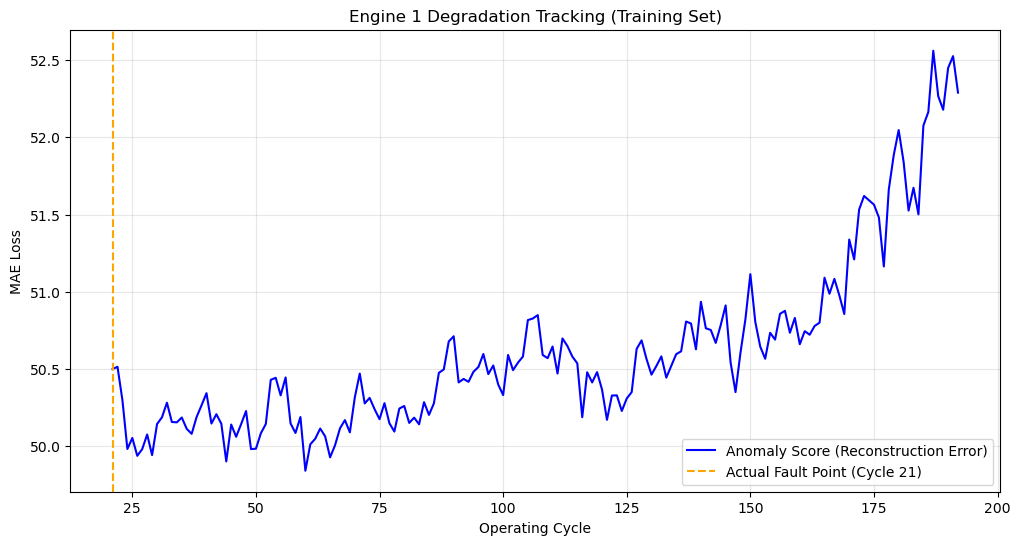

In [37]:
# Visualize results (from Nish)
df = df_train
unit_id = 1
unit_mask = df_train['Unit'] == unit_id
X_unit, cycles_unit, ruls_unit = gen_sequences_and_labels(df[unit_mask], WINDOW_SIZE)

unit_preds = model.predict(X_unit)
unit_mae = np.mean(np.abs(unit_preds - X_unit), axis=(1, 2))

# Find the exact cycle where RUL hits our 125 threshold
fault_cycle = cycles_unit[ruls_unit <= HEALTHY_RUL_THRESHOLD][0] if any(ruls_unit <= HEALTHY_RUL_THRESHOLD) else cycles_unit[-1]

plt.figure(figsize=(12, 6))
plt.plot(cycles_unit, unit_mae, label='Anomaly Score (Reconstruction Error)', color='blue')
# plt.axhline(y=smart_threshold, color='red', linestyle='-', label=f'Smart Threshold ({smart_threshold:.4f})')
plt.axvline(x=fault_cycle, color='orange', linestyle='--', label=f'Actual Fault Point (Cycle {fault_cycle})')

plt.title(f'Engine {unit_id} Degradation Tracking (Training Set)')
plt.xlabel('Operating Cycle')
plt.ylabel('MAE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show(block=False) # Prevent visualization from freezing the script before testing
